# Class 18: Basics of Astropy and Astroquery
## Objective: Learn how to query astronomical databases with python

Astroquery is a python package that can query a large number of astronomical databases. Queries are typically written with the **Astronomical Data Query Language (ADQL)**. This is based on **Structured Query Language (SQL)**, which is used in a broad range of science fields and industry to query **relational databases.** The combination of SQL and relational databases enable extremely rapid searches. 

You will likely need to install the `astroquery` package as it does not come as part of Anaconda (although `astropy` does. Install `astroquery` by opening a terminal in Jupyter Lab and typing:

`conda install -c astropy astroquery`

This will install astroquery from the `astropy` channel.

(You can ignore warnings about a user account password.)

This notebook is based on https://tingyuansen.github.io/coding_essential_for_astronomers/lectures/lecture13-astroquery-astropy-units-coordinates.html

In [3]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

from astropy.coordinates import SkyCoord
import astropy.units as u

# Import Gaia query module from astroquery package
from astroquery.gaia import Gaia

# Set display options for better visibility
pd.set_option('display.max_rows', 100)      # Show up to 100 rows before truncating
pd.set_option('display.max_columns', 20)    # Show up to 20 columns before truncating
pd.set_option('display.width', 120)         # Wider display for more columns
pd.set_option('display.precision', 3)       # Show 3 decimal places
pd.set_option('display.float_format', '{:.3f}'.format)  # Consistent float formatting

## Section 1: Recreate the GAIA catalog for Class 15

This query reproduces the catalog. The query text `full_query` has `SELECT`, `FROM`, and `WHERE` blocks. The `Gaia.launch_job()` sends the query, `job.get_results()` stores the results (as an Astropy Table), and the `.to_pandas()` method then converts the results to a pandas data frame.

You can find complete documentation for GAIA Data Release 3 (GAIA DR3) online: https://www.cosmos.esa.int/web/gaia/dr3#

In [5]:
# The full query that created your Pandas sample

full_query = """
SELECT TOP 5000
    source_id,
    ra, dec,
    parallax, parallax_error,
    pmra, pmra_error,
    pmdec, pmdec_error,
    radial_velocity, radial_velocity_error,
    phot_g_mean_mag,
    phot_bp_mean_mag,
    phot_rp_mean_mag,
    ruwe
FROM gaiadr3.gaia_source
WHERE parallax > 10
    AND parallax/parallax_error > 5
    AND radial_velocity IS NOT NULL
    AND phot_g_mean_mag < 15
    AND ruwe < 1.4
"""
# ORDER BY random_index

print("Querying Gaia DR3 for 5000 high-quality nearby stars...")
print("This may take 10-30 seconds...")

job = Gaia.launch_job(full_query) # launches a synchronous query
results = job.get_results()
gaia = results.to_pandas()

print(f"\nRetrieved {len(gaia)} stars")
print(f"Catalog Shape: {gaia.shape}")
print("\nFirst few rows:")
gaia.head()

Querying Gaia DR3 for 5000 high-quality nearby stars...
This may take 10-30 seconds...

Retrieved 5000 stars
Catalog Shape: (5000, 15)

First few rows:


,SOURCE_ID,ra,dec,parallax,parallax_error,pmra,pmra_error,pmdec,pmdec_error,radial_velocity,radial_velocity_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,ruwe
0,824294419098240,47.210,2.729,12.909,0.034,4.891,0.035,-92.906,0.027,-7.031,4.699,14.395,15.821,13.224,1.273
1,1564678061440128,43.711,2.746,10.636,0.018,76.454,0.019,-4.299,0.019,17.383,0.573,11.449,12.052,10.711,1.086
2,1950331764866304,45.758,3.928,11.493,0.016,75.348,0.017,-69.195,0.015,18.442,0.209,8.992,9.264,8.545,1.073
3,3416461801028736,46.784,4.023,11.601,0.068,-86.045,0.058,-26.804,0.046,-30.494,3.875,14.154,14.848,12.575,1.186
4,4061462809542400,47.901,5.727,22.917,0.038,146.420,0.031,-208.567,0.027,16.762,3.119,14.366,15.892,13.164,1.172


In [6]:
# Add derived columns (same as in the Pandas lectures)
gaia['distance_pc'] = 1000 / gaia['parallax']
gaia['abs_g_mag'] = gaia['phot_g_mean_mag'] - 5 * np.log10(gaia['distance_pc']/10)
gaia['bp_rp'] = gaia['phot_bp_mean_mag'] - gaia['phot_rp_mean_mag']

print("Summary statistics:")
print(f"Distance range: {gaia['distance_pc'].min():.1f} - {gaia['distance_pc'].max():.1f} pc")
print(f"Magnitude range: {gaia['phot_g_mean_mag'].min():.2f} - {gaia['phot_g_mean_mag'].max():.2f}")
print(f"Color range: {gaia['bp_rp'].min():.2f} - {gaia['bp_rp'].max():.2f}")
print(f"Stars with radial velocity: {gaia['radial_velocity'].notna().sum()}")

Summary statistics:
Distance range: 7.6 - 100.0 pc
Magnitude range: 4.15 - 15.00
Color range: -0.14 - 3.51
Stars with radial velocity: 5000


**Test your understanding:** Read in the csv file you downloaded from carmen (or GitHub) from the Pandas lecture, add the same derived columns, and compare the summary statistics. 

In [7]:
import os 

os.getcwd()

df = pd.read_csv('data_gaia_dr3.csv')

df['distance_pc'] = 1000 / df['parallax']
df['abs_g_mag'] = df['phot_g_mean_mag'] - 5 * np.log10(df['distance_pc']/10)
df['bp_rp'] = df['phot_bp_mean_mag'] - df['phot_rp_mean_mag']

print("Summary statistics:")
print(f"Distance range: {df['distance_pc'].min():.1f} - {df['distance_pc'].max():.1f} pc")
print(f"Magnitude range: {df['phot_g_mean_mag'].min():.2f} - {df['phot_g_mean_mag'].max():.2f}")
print(f"Color range: {df['bp_rp'].min():.2f} - {df['bp_rp'].max():.2f}")
print(f"Stars with radial velocity: {df['radial_velocity'].notna().sum()}")



Summary statistics:
Distance range: 9.3 - 100.0 pc
Magnitude range: 4.15 - 15.00
Color range: -0.10 - 3.77
Stars with radial velocity: 5000


## Section 2: Query other databases

**Simbad** (short for Set of Identifications, Measurements, and Bibliography for Astronomical Data) is an object-oriented database that stores information about astronomical objects. 

**Vizier** contains catalogs from published research papers

 MAIN_ID         RA           DEC      ...     COO_BIBCODE     SCRIPT_NUMBER_ID
              "h:m:s"       "d:m:s"    ...                                     
---------- ------------- ------------- ... ------------------- ----------------
TRAPPIST-1 23 06 29.3684 -05 02 29.037 ... 2020yCat.1350....0G                1


Query 2MASS near TRAPPIST-1
Found 1 catalog match(es)
Retrieved 50 sources
   RAJ2000  DEJ2000            _2MASS   Jmag  e_Jmag   Hmag  e_Hmag   Kmag  e_Kmag Qflg Rflg Bflg Cflg  Xflg  Aflg
0  346.600   -5.132  23062407-0507535 16.752   0.141 15.845   0.159 16.016     NaN  BCU  220  110  000     0     0
1  346.635   -5.140  23063229-0508252 13.217   0.036 12.649   0.040 12.329   0.033  EAA  222  111  000     0     0
2  346.644   -5.131  23063445-0507511 12.326   0.022 11.701   0.024 11.495   0.023  AAA  222  111  000     0     0
3  346.664   -5.128  23063928-0507422 14.406   0.032 13.805   0.037 13.617   0.041  AAA  222  111  000     0     0
4  346.675   -5.119  2306421

Text(0, 0.5, 'Declination [dec]')

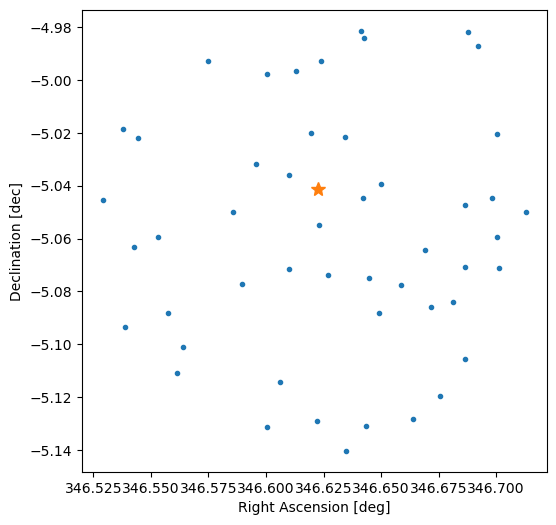

In [8]:
# Import these query modules from astroquery
from astroquery.simbad import Simbad
from astroquery.vizier import Vizier

# Look up TRAPPIST-1 (system with 7 rocky planets)
result = Simbad.query_object("TRAPPIST-1")
print(result)

# Calculate the RA and Dec:
coords = SkyCoord(ra=result['RA'][0], dec=result['DEC'][0], unit=(u.hourangle, u.deg), frame='icrs')

print('\n\nQuery 2MASS near TRAPPIST-1') 
# Query 2MASS catalog near TRAPPIST-1 (within 0.1 degrees)
result = Vizier.query_region(
    "TRAPPIST-1",
    radius="0.1 deg",
    catalog='II/246/out'  # 2MASS catalog identifier
)

print(f"Found {len(result)} catalog match(es)")
if len(result) > 0:
    df_2mass = result[0].to_pandas()
    print(f"Retrieved {len(df_2mass)} sources")
    print(df_2mass.head())

# Plot the star positions
fig, ax = plt.subplots(1,1,figsize=(6,6))
ax.plot(df_2mass['RAJ2000'], df_2mass['DEJ2000'], '.')
ax.plot(coords.ra.deg, coords.dec.deg, '*', ms=10, label="TRAPPIST-1")
ax.set_xlabel("Right Ascension [deg]")
ax.set_ylabel("Declination [dec]")

**Test your understanding:** Perform a similar query around another bright star and create a plot.

 MAIN_ID        RA           DEC      ...     COO_BIBCODE     SCRIPT_NUMBER_ID
             "h:m:s"       "d:m:s"    ...                                     
--------- ------------- ------------- ... ------------------- ----------------
* alf CMa 06 45 08.9172 -16 42 58.017 ... 2007A&A...474..653V                1


Query 2MASS near Sirius A
Found 1 catalog match(es)
Retrieved 50 sources
   RAJ2000  DEJ2000            _2MASS   Jmag  e_Jmag   Hmag  e_Hmag   Kmag  e_Kmag Qflg Rflg Bflg Cflg  Xflg  Aflg
0  101.259  -16.811  06450220-1648380 16.026     NaN 15.613   0.130 15.135   0.147  UBB   22   11  0cc     0     0
1  101.258  -16.811  06450192-1648400 16.690     NaN 15.661   0.109 15.436   0.211  UBC   22   11  0cc     0     0
2  101.291  -16.806  06450982-1648220 15.584     NaN 15.452   0.099 15.056   0.147  UAB   22   11  0cc     0     0
3  101.298  -16.807  06451150-1648266 15.663     NaN 15.444   0.093 14.902   0.130  UAB   22   11  0cc     0     0
4  101.294  -16.803  06451060-1648

Text(0, 0.5, 'Declination [dec]')

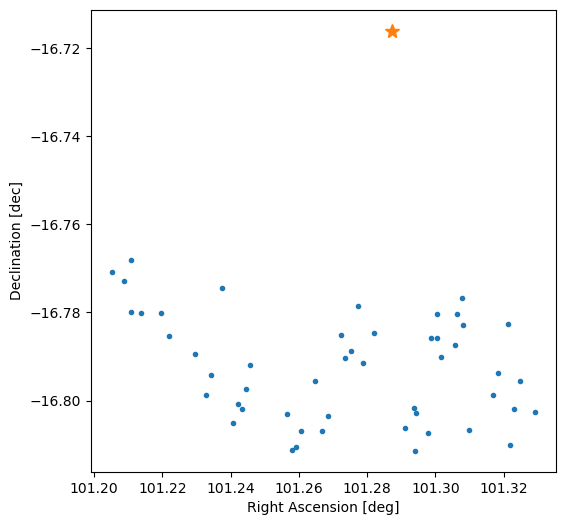

In [9]:
# Your code here
# Look up HD 93129A
result = Simbad.query_object("Sirius A")
print(result)

# Calculate the RA and Dec:
coords = SkyCoord(ra=result['RA'][0], dec=result['DEC'][0], unit=(u.hourangle, u.deg), frame='icrs')

print('\n\nQuery 2MASS near Sirius A') 
# Query 2MASS catalog near TRAPPIST-1 (within 0.1 degrees)
result = Vizier.query_region(
    "Sirius A",
    radius="0.1 deg",
    catalog='II/246/out'  # 2MASS catalog identifier
)

print(f"Found {len(result)} catalog match(es)")
if len(result) > 0:
    df_2mass = result[0].to_pandas()
    print(f"Retrieved {len(df_2mass)} sources")
    print(df_2mass.head())

# Plot the star positions
fig, ax = plt.subplots(1,1,figsize=(6,6))
ax.plot(df_2mass['RAJ2000'], df_2mass['DEJ2000'], '.')
ax.plot(coords.ra.deg, coords.dec.deg, '*', ms=10, label="Sirius A")
ax.set_xlabel("Right Ascension [deg]")
ax.set_ylabel("Declination [dec]")


## Section 3: Units and Constants

The `astropy` package has both an `astropy.units` module and an `astropy.constants` module that can make code more clear and prevent errors. 

In [10]:
# Import units and constants modules from astropy
import astropy.units as u
import astropy.constants as const

# Create a quantity: distance to Proxima Centauri
distance = 1.3 * u.parsec

print(f"Distance: {distance}")
print(f"Type: {type(distance)}")
print(f"Value: {distance.value}") # numerical value only
print(f"Unit: {distance.unit}") # units only

# Convert parsecs to light years with the .to() method
distance_ly = distance.to(u.lightyear)
print(f"Distance in light years: {distance_ly}")

# Convert to meters
distance_m = distance.to(u.meter)
print(f"Distance in meters: {distance_m:.3e}")

# Convert to kilometers  
distance_km = distance.to(u.km)
print(f"Distance in kilometers: {distance_km:.3e}")

# Calculate travel time to Proxima Centauri at 1% speed of light
distance = 1.3 * u.parsec
speed = 0.01 * const.c  # const.c is the speed of light

travel_time = distance / speed

# Unit conversion example
print(f"Speed: {speed}")
print(f"Travel time: {travel_time}")
print(f"Travel time in years: {travel_time.to(u.year):.1f}")

# Example calculation of the Earth's escape velocity
v_escape = np.sqrt(2 * const.G * const.M_earth / const.R_earth)

print(f"Escape velocity: {v_escape}")
print(f"In km/s: {v_escape.to(u.km/u.s):.2f}")

# Compare to known value
print(f"\nKnown value: ~11.2 km/s")

Distance: 1.3 pc
Type: <class 'astropy.units.quantity.Quantity'>
Value: 1.3
Unit: pc
Distance in light years: 4.240032910317663 lyr
Distance in meters: 4.011e+16 m
Distance in kilometers: 4.011e+13 km
Speed: 2997924.58 m / s
Travel time: 4.336333237575977e-07 pc s / m
Travel time in years: 424.0 yr
Escape velocity: 11179.90725689236 m / s
In km/s: 11.18 km / s

Known value: ~11.2 km/s


**Test your understanding:** Try to add two numbers with inconsistent units (e.g. `u.parsec` and `u.km / u.s`) and see what happens (look for a `UnitConversionError`)

In [11]:
# Enter your code here

x = 5 * u.meter
y = 6 * u.s



## Section 4: Sky Coordinates

Astronomy has many coordinate systems. 

Right Ascension and Declination are commonly used for sky coordinates, although these could be in **hh:mm*ss** **dd:mm:ss** format or in degrees, and be defined for different epochs. 

We use Galactic latitude and longitude for coordinates relative to the center and plane of the Milky Way. 

This example shows how to query stars from GAIA that are randomly distributed across the sky and transform between celestial and Galactic coordinate systems. Note this may take a minute or more to run. 

The GAIA catalog includes a column called `random_index` that is designed to facilitate the selection of smaller, statistically representative subsets of the massive Gaia data. Each row has a random integer between 1 and N, where N is the length of the catalog. 

`MOD(random_index, 500) = 0` is the **modulus operator**. It returns just the *remainder* (non-integer part) of the first number divided by the second number, so for example `MOD(1250,500)` returns 0.5 and `MODS(10000)` returns 0.0. In the example below, only objects evenly divisible by 500 pass the selection criterion. (For a catalog with 2 billion entries, this randomly trims the catalog down to about 4 million. 

This is a longer query than the previous one, so we are using `.launch_job_async()` instead of `.launch_job_synch()` so the query does not timeout.

In [12]:
random_allsky_query = """
SELECT 
    source_id, ra, dec, parallax, parallax_error, 
    pmra, pmdec, radial_velocity,
    phot_g_mean_mag
FROM gaiadr3.gaia_source  
WHERE parallax BETWEEN 1 AND 5
    AND phot_g_mean_mag < 16
    AND parallax/parallax_error > 5
    AND MOD(random_index, 500) = 0  -- Make this number larger/smaller to get fewer/more stars
"""

print("Launching random all-sky query (Scanning the whole sky)...")
job = Gaia.launch_job_async(random_allsky_query) # this is an asynchronous query
allsky = job.get_results().to_pandas()

Launching random all-sky query (Scanning the whole sky)...
INFO: Query finished. [astroquery.utils.tap.core]


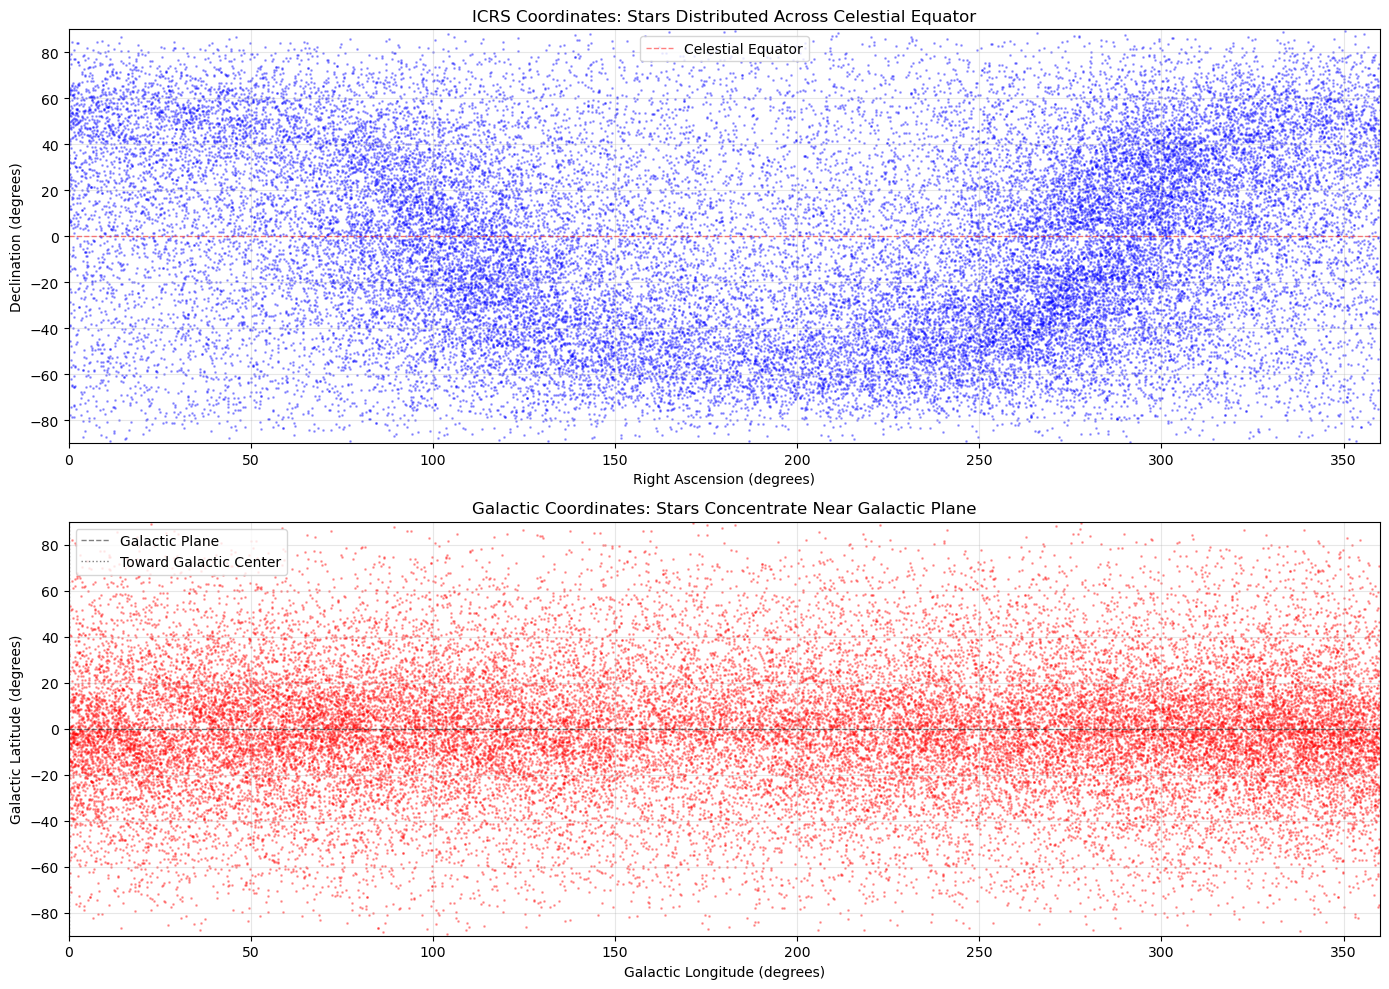

In [13]:
# coordinate processing 
allsky['distance_pc'] = 1000.0 / allsky['parallax']

# create a SkyCoord class for the coordinates associated with this catalog
allsky_coords = SkyCoord(
    ra=allsky['ra'].values * u.deg,
    dec=allsky['dec'].values * u.deg,
    distance=allsky['distance_pc'].values * u.pc,
    frame='icrs'
)

# Transform to Galactic coordinates
allsky_coords_gal = allsky_coords.galactic

# Create a plot that shows the sources in both celestial and Galactic coordinates
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top: ICRS (RA/Dec)
axes[0].scatter(allsky_coords.ra.deg, allsky_coords.dec.deg, s=1, alpha=0.3, c='blue')
axes[0].set_xlabel('Right Ascension (degrees)')
axes[0].set_ylabel('Declination (degrees)')
axes[0].set_title('ICRS Coordinates: Stars Distributed Across Celestial Equator')
axes[0].set_xlim(0, 360)
axes[0].set_ylim(-90, 90)
axes[0].grid(alpha=0.3)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Celestial Equator')
axes[0].legend()

# Bottom: Galactic
axes[1].scatter(allsky_coords_gal.l.deg, allsky_coords_gal.b.deg, s=1, alpha=0.3, c='red')
axes[1].set_xlabel('Galactic Longitude (degrees)')
axes[1].set_ylabel('Galactic Latitude (degrees)')
axes[1].set_title('Galactic Coordinates: Stars Concentrate Near Galactic Plane')
axes[1].set_xlim(0, 360)
axes[1].set_ylim(-90, 90)
axes[1].grid(alpha=0.3)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Galactic Plane')
axes[1].axvline(0, color='black', linestyle=':', linewidth=1, alpha=0.5, label='Toward Galactic Center')
axes[1].legend()

plt.tight_layout()
plt.show()

**Test your understanding:** Read through the following code and try to interpret the plot. Specifically:
1. What does the mask do?
2. Why is the plane of the Milky Way not very clear in the new figure below? 

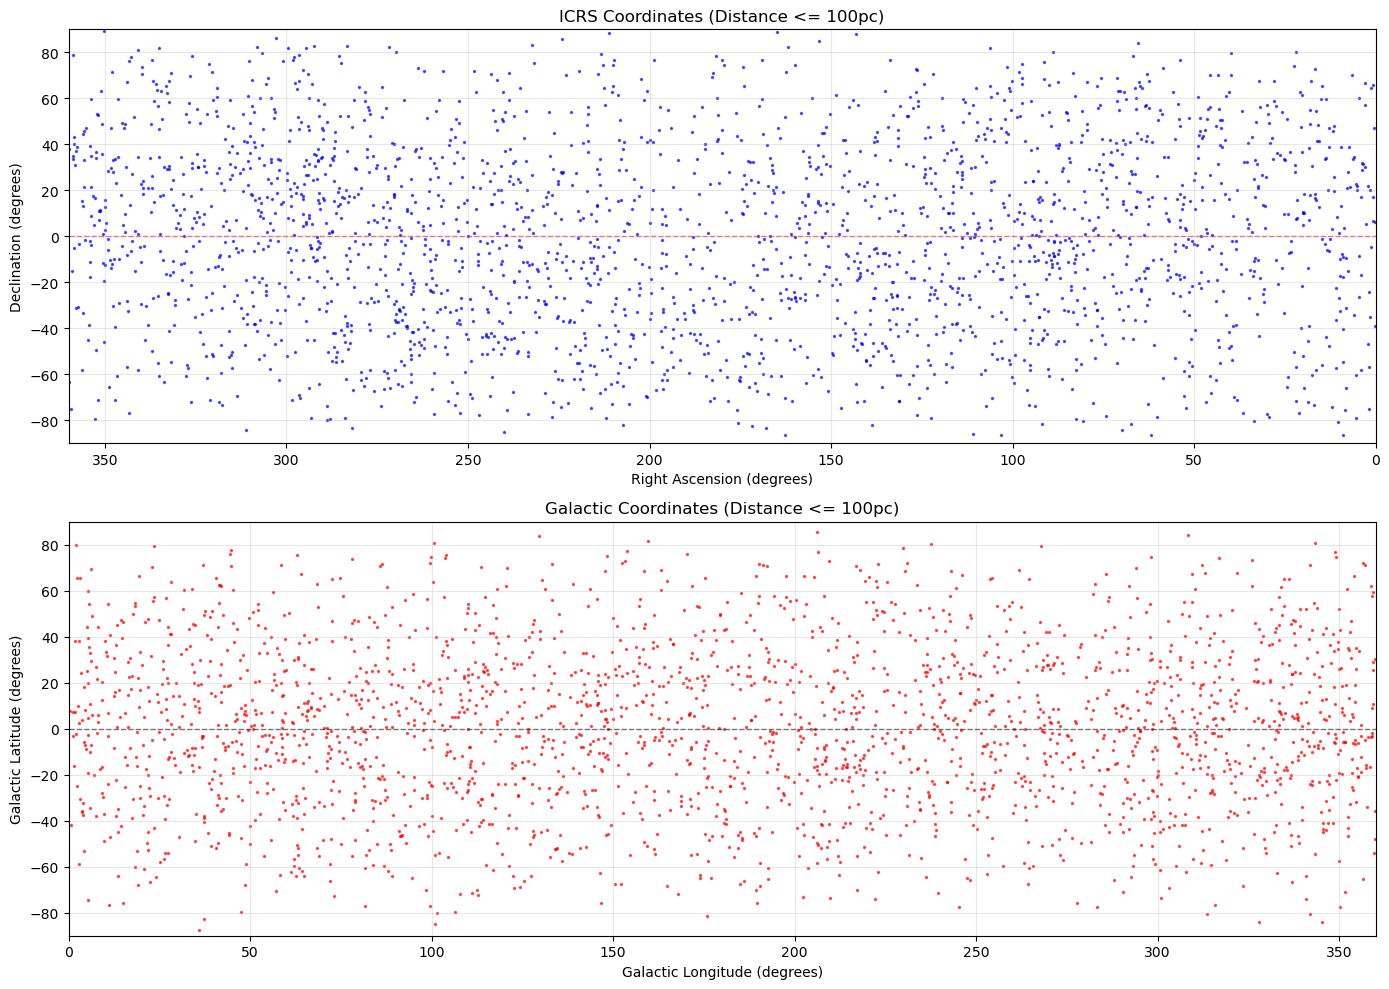

In [14]:
mask = allsky['distance_pc'] <= 300.
ra_filtered = allsky_coords.ra.deg[mask]
dec_filtered = allsky_coords.dec.deg[mask]
l_filtered = allsky_coords_gal.l.deg[mask]
b_filtered = allsky_coords_gal.b.deg[mask]

# Create comparison plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top: ICRS (RA/Dec)
# Using filtered RA and Dec
axes[0].scatter(ra_filtered, dec_filtered, s=2, alpha=0.6, c='blue')
axes[0].set_xlabel('Right Ascension (degrees)')
axes[0].set_ylabel('Declination (degrees)')
axes[0].set_title('ICRS Coordinates (Distance <= 100pc)')
axes[0].set_xlim(360, 0) # Astronomers often flip RA to match the sky
axes[0].set_ylim(-90, 90)
axes[0].grid(alpha=0.3)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Equator')

# Bottom: Galactic
# Using filtered l and b
axes[1].scatter(l_filtered, b_filtered, s=2, alpha=0.6, c='red')
axes[1].set_xlabel('Galactic Longitude (degrees)')
axes[1].set_ylabel('Galactic Latitude (degrees)')
axes[1].set_title('Galactic Coordinates (Distance <= 100pc)')
axes[1].set_xlim(0, 360)
axes[1].set_ylim(-90, 90)
axes[1].grid(alpha=0.3)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Plane')

plt.tight_layout()
plt.show()

## Section 5: Cross Matching

We often want to work with astronomy data from multiple catalogs, often obtained with observations at multiple wavelengths. It is thus very valuable to be able to cross match catalogs. 

You can merge Pandas DataFrames with `pd.merge()`. This works well if both catalogs use the same identification systems. 

If the catalogs do not use the same identification system, then the best choice is to match by position. Yet because catalogs are different, the coordinates may not exactly agree. 

Astropy includes `.match_to_catalog()` method for the `SkyCoord` class. It finds the nearest match for each object in the first catalog. It returns the indices of the matches, on-sky distances, and 3D distances (if distances are available). 

There is also a `.separation()` method that computes the angular distance between two coordinates.

Here is an example random dataset that matches two catalogs: 

In [15]:
# A 2' x 2' box centered near a dense region (e.g., near the Galactic Center or a cluster)
# Using RA=266.4, Dec=-29.0 (near the Galactic Center region)
# Note how quick this query runs, since it is focused on a very small region of the sky 
small_gaia_query = """
SELECT 
    source_id, ra, dec, parallax, parallax_error, 
    pmra, pmdec, radial_velocity, phot_g_mean_mag
FROM gaiadr3.gaia_source  
WHERE CONTAINS(
    POINT('ICRS', ra, dec),
    BOX('ICRS', 266.41, -29.01, 0.033, 0.033) -- 0.033 degrees is ~2 arcminutes
) = 1
AND phot_g_mean_mag < 19
"""

job = Gaia.launch_job(small_gaia_query) # we'll use a synchronous job as we expect this to be quick
smallgaia = job.get_results().to_pandas()

smallgaia['distance_pc'] = 1000.0 / smallgaia['parallax']

# Get the GAIA catalog coordinates from allsky
coords_smallgaia = SkyCoord(
    ra=smallgaia['ra'].values * u.deg,
    dec=smallgaia['dec'].values * u.deg,
    distance=smallgaia['distance_pc'].values * u.pc,
    frame='icrs'
)
n_obs = int(0.5*len(smallgaia)) # just use about half of our small GAIA catalog for the alternate survey

observed_indices = np.random.choice(len(coords_smallgaia), n_obs, replace=False)

# Create a fake alternative survey we want to match to by randomly scrambling the small GAIA catalog
altsurvey = pd.DataFrame({
    'survey_id': range(1, n_obs+1),  # Survey's own ID system
    'ra_survey': smallgaia['ra'].values[observed_indices] + np.random.normal(0, 0.0003, n_obs),  # ~1 arcsec errors
    'dec_survey': smallgaia['dec'].values[observed_indices] + np.random.normal(0, 0.0003, n_obs),
    'measured_flux': np.random.uniform(100, 10000, n_obs),
    'survey_date': pd.date_range('2024-01-01', periods=n_obs, freq='1D')
})

# Survey coordinates
coords_altsurvey = SkyCoord(
    ra=altsurvey['ra_survey'].values*u.deg,
    dec=altsurvey['dec_survey'].values*u.deg,
    frame='icrs'
)

print(f"Created survey catalog with {len(altsurvey)} observations")
print("\nFirst few entries:")
altsurvey.head()

print(f"Small Gaia catalog: {len(coords_smallgaia)} stars")
print(f"Alternative Survey catalog: {len(coords_altsurvey)} observations")

Created survey catalog with 23 observations

First few entries:
Small Gaia catalog: 46 stars
Alternative Survey catalog: 23 observations


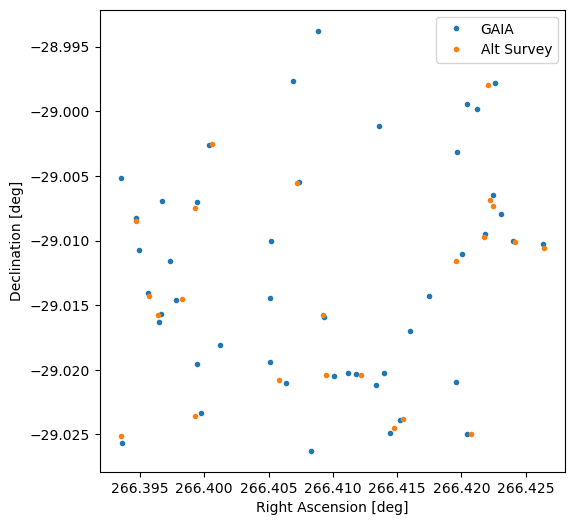

In [16]:
# Create a figure that shows the two catalogs
fig, ax = plt.subplots(1,1,figsize=(6,6))
ax.plot(coords_smallgaia.ra.deg, coords_smallgaia.dec.deg,  '.', label="GAIA") 
ax.plot(coords_altsurvey.ra.deg, coords_altsurvey.dec.deg,  '.', label="Alt Survey") 
ax.set_xlabel("Right Ascension [deg]")
ax.set_ylabel("Declination [deg]") 
ax.legend()

Now we will match the two catalogs. This uses a matching radius of 3.5 arcseconds, which means that it will only associate two objects if they are within this angular separation. 

In [17]:
# Identify matches as objects with a separation of less than 3.5 arcseconds
match_radius = 3.5 * u.arcsec
idx, sep, _ = coords_altsurvey.match_to_catalog_sky(coords_smallgaia)
good_matches = sep < match_radius   # boolean mask 

# Get the survey rows that have matches
altsurvey_matched = altsurvey[good_matches].reset_index(drop=True)

# Get the corresponding Gaia rows (using the indices returned by match_to_catalog_sky)
# This creates a dataframe with the same number of rows as survey_matched
smallgaia_matched = smallgaia.iloc[idx[good_matches]].reset_index(drop=True)

# Since they are both reset and have the same number of rows, we just stack them horizontally
merged = pd.concat([altsurvey_matched, smallgaia_matched], axis=1)

# Add a column with the separation to use as a quality indicator
merged['match_separation_arcsec'] = sep[good_matches].to(u.arcsec).value

print(f"Merged Catalog Shape: {merged.shape}")
merged.head()

Merged Catalog Shape: (23, 16)


,survey_id,ra_survey,dec_survey,measured_flux,survey_date,SOURCE_ID,ra,dec,parallax,parallax_error,pmra,pmdec,radial_velocity,phot_g_mean_mag,distance_pc,match_separation_arcsec
0,1,266.422,-29.007,383.446,2024-01-01,4057481821012592512,266.422,-29.006,0.378,0.073,3.091,-0.617,NaN,16.669,2646.554,1.743
1,2,266.399,-29.008,1672.132,2024-01-02,4057481997113302144,266.399,-29.007,0.256,0.084,1.558,-4.319,NaN,16.931,3904.213,1.762
2,3,266.407,-29.006,5959.355,2024-01-03,4057481786652854784,266.407,-29.005,0.908,0.151,4.302,1.137,NaN,18.007,1101.574,0.407
3,4,266.396,-29.014,3323.230,2024-01-04,4057481889732059520,266.396,-29.014,0.512,0.170,-9.102,-1.781,NaN,18.247,1953.131,0.744
4,5,266.422,-28.998,3563.616,2024-01-05,4057481821013456256,266.423,-28.998,0.079,0.213,0.601,-1.813,NaN,18.336,12719.634,1.737


**Test your understanding:** Create a histogram of the separations between the matched objects. Was it a good idea to limit the matches to those within 3.5 arcseconds? Why or why not? 

Text(0.5, 0, 'Separation')

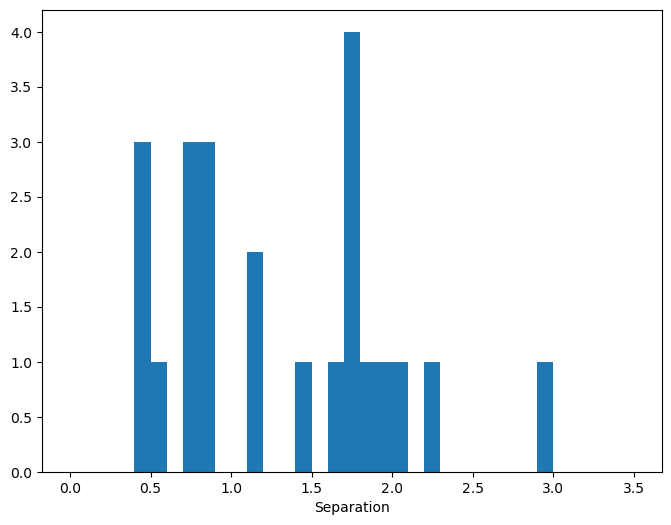

In [18]:
# Enter your code here
fig,ax = plt.subplots(1,1,figsize=(8,6))
ax.hist(merged['match_separation_arcsec'], bins=35, range=(0,3.5))
ax.set_xlabel('Separation')